In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# handling missing value

In [4]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [5]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# feature engineering

In [6]:
df["age"] = 2026 - df["Year_Birth"]

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [8]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)
reference_day = df["Dt_Customer"].max()
df["customer_tenuar_days"] = reference_day - df["Dt_Customer"]

In [9]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_tenuar_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663 days
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113 days
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312 days
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139 days
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161 days


In [10]:
df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'customer_tenuar_days'],
      dtype='str')

In [11]:
# spending
df["total_spending"] = df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [12]:
# total children
df["total_children"] = df["Kidhome"]+df["Teenhome"]

In [13]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_tenuar_days,total_spending,total_children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663 days,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113 days,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312 days,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139 days,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161 days,422,1


In [14]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [15]:
# eduction
df["Education"] = df["Education"].replace({
    "Basic":"undergraduate","2n Cycle":"undergraduate",
    "Graduation":"graduate",
    "PhD":"postgraduate","Master":"postgraduate",
})

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_tenuar_days,total_spending,total_children
0,5524,1957,graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663 days,1617,0
1,2174,1954,graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113 days,27,2
2,4141,1965,graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312 days,776,0
3,6182,1984,graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139 days,53,1
4,5324,1981,postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161 days,422,1


In [17]:
df["Education"].value_counts()

Education
graduate         1127
postgraduate      856
undergraduate     257
Name: count, dtype: int64

In [18]:
#marriatal status
df["living_together"] = df["Marital_Status"].replace({
    "Married":"partner","Together":"partner",
    "Single":"alone","Divorced":"alone","Widow":"alone","Absurd":"alone","YOLO":"alone",
})

In [19]:
df["living_together"].value_counts()

living_together
partner    1444
alone       793
Alone         3
Name: count, dtype: int64

In [20]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_tenuar_days,total_spending,total_children,living_together
0,5524,1957,graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663 days,1617,0,alone
1,2174,1954,graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113 days,27,2,alone
2,4141,1965,graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312 days,776,0,partner
3,6182,1984,graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139 days,53,1,partner
4,5324,1981,postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161 days,422,1,partner


In [21]:
#drop_columns
col = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending =["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
col_to_drop = col + spending
df_cleaned = df.drop(columns=col_to_drop)

In [22]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_tenuar_days,total_spending,total_children,living_together
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,alone
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,alone
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,partner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,partner
4,postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,partner


# outlier

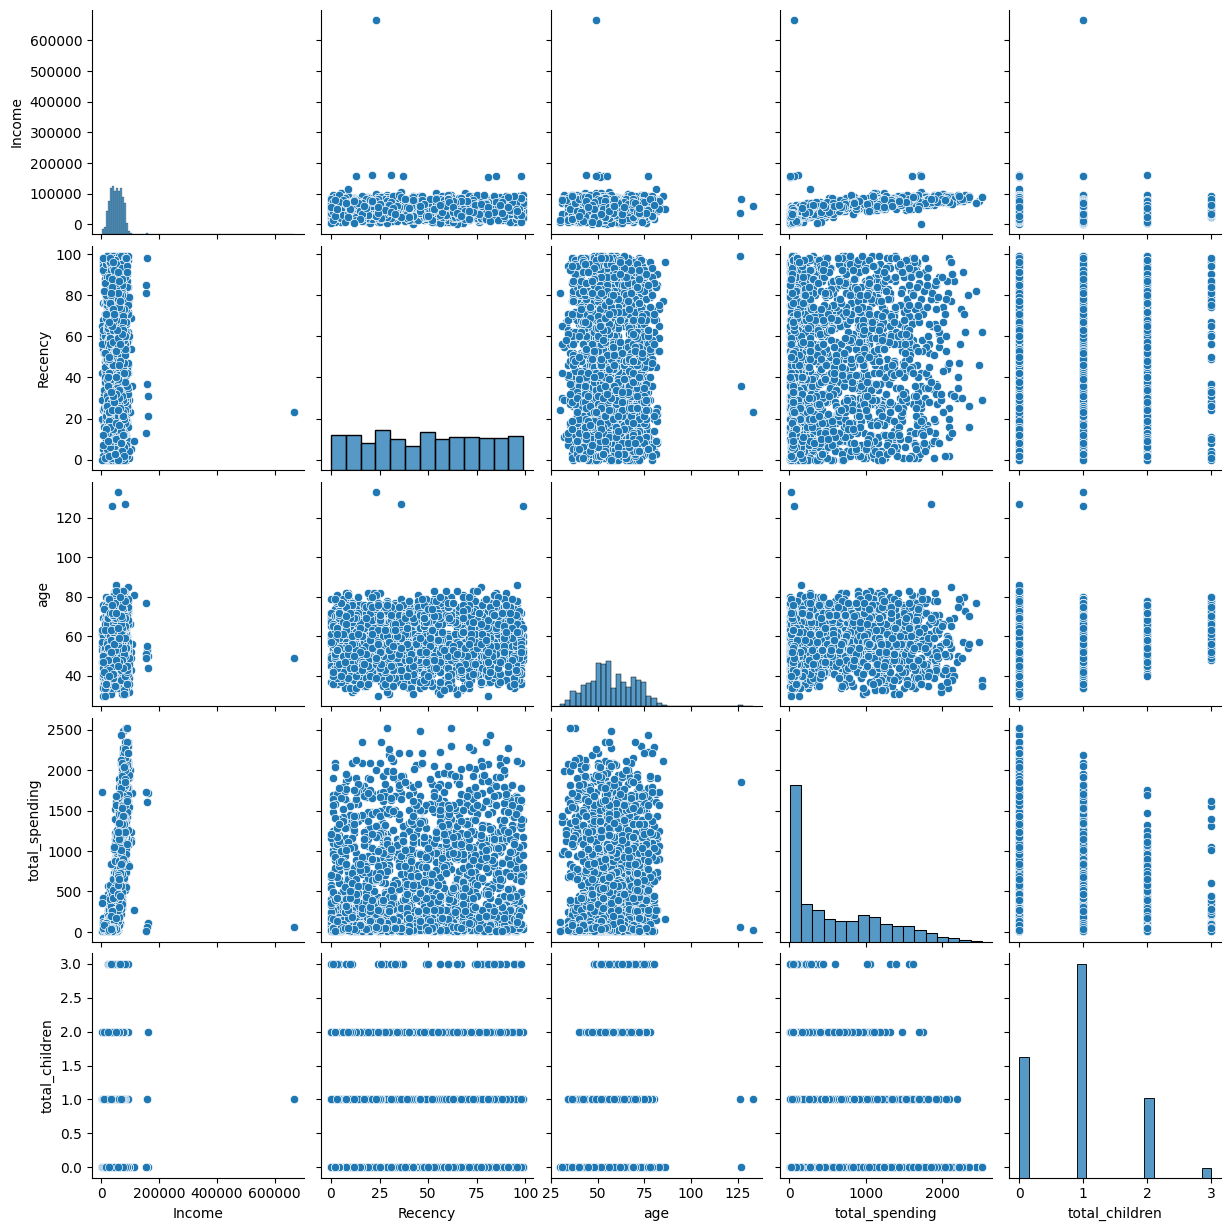

In [23]:
col = ["Income","Recency","age","total_spending","total_children"]
sns.pairplot(df_cleaned[col])

In [24]:
print("data size with outlier",len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]
print("data size without outlier",len(df_cleaned))


data size with outlier 2240
data size without outlier 2236


# HEATMAP

In [25]:
corr = df_cleaned.corr(numeric_only = True)
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,total_spending,total_children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.265615,-0.169451
age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,0.113618,0.095512


<Axes: >

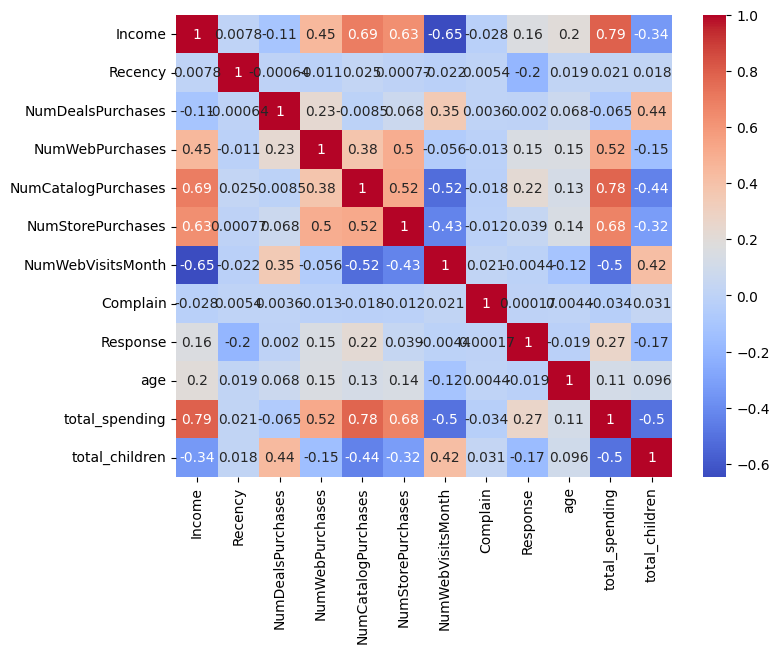

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm"
)

# encoding and scaling

In [27]:
x = df_cleaned

In [28]:
x["customer_tenuar_days"] = x["customer_tenuar_days"].dt.days
x = pd.get_dummies(x,columns=["living_together","Education"],dtype = int)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# visualized 

In [30]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
x_pca = pca.fit_transform(x_scaled)

<Axes: >

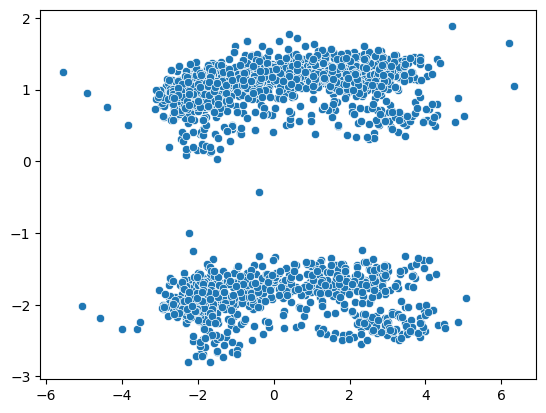

In [31]:
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1])

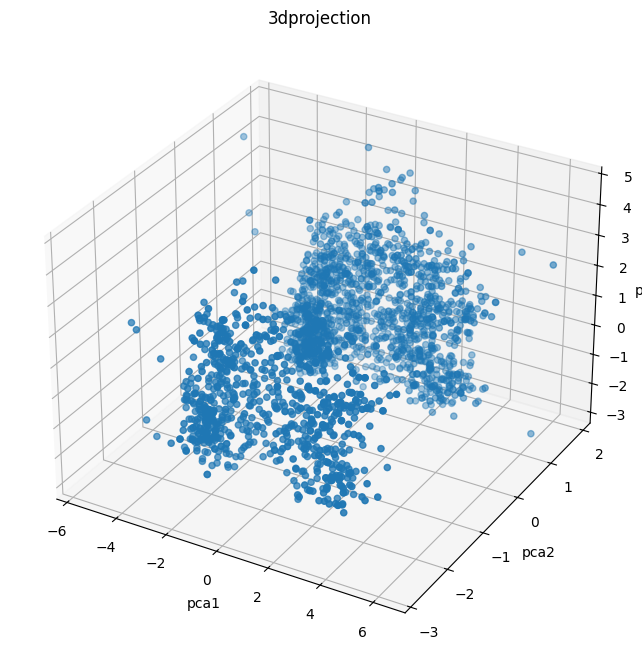

In [32]:
fig = plt.figure(figsize=(8,10))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    x_pca[:,0],
    x_pca[:,1],
    x_pca[:,2]
)
ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3dprojection")
plt.show()


In [46]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k , random_state = 42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [47]:
knee =  KneeLocator(range(1,11),wcss,curve="convex",direction = "decreasing")
optimal_k = knee.elbow
print("best-k",optimal_k)

best-k 3


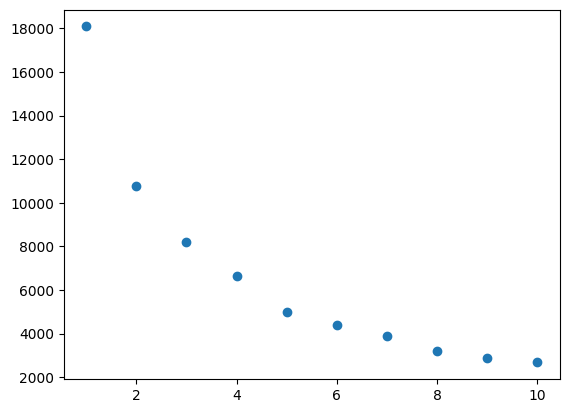

In [49]:
plt.scatter(range(1,11),wcss,marker="o")

In [55]:
# kmeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4,random_state=42)
labels = kmeans.fit_predict(x_pca)

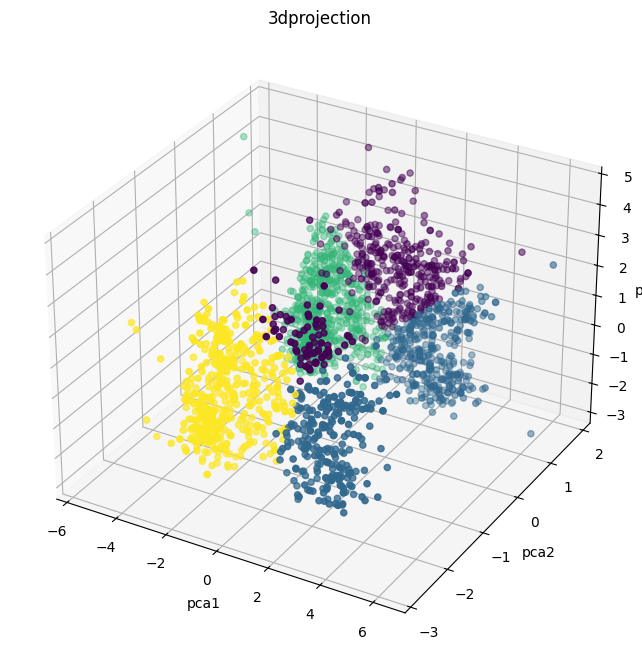

In [56]:
fig = plt.figure(figsize=(8,10))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    x_pca[:,0],
    x_pca[:,1],
    x_pca[:,2],
    c = labels,
)
ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3dprojection")
plt.show()